# Multilingual Statistical Significance Tests: Adult-Child WER Gap

**Research question:** When trained on multilingual adult and child speech in English, Dutch, German, and Polish, does the MoE encoder reduce the adult-child WER gap relative to a dense baseline, and does any reduction vary across languages?

**Method:** Paired speaker-level non-parametric bootstrap (Bisani & Ney, 2004). Speakers are resampled with replacement; all $p$-values are corrected using Benjamini-Hochberg FDR at $q = 0.05$.

This notebook reports three kinds of evidence:

1. **Gap test (primary).** Directly tests whether MoE reduces the adult-child WER gap:

$$\Delta\text{Gap} = \underbrace{(\text{WER}_{\text{child},A} - \text{WER}_{\text{adult},A})}_{\text{gap for model A (MoE)}} \;-\; \underbrace{(\text{WER}_{\text{child},B} - \text{WER}_{\text{adult},B})}_{\text{gap for model B (Dense)}}$$

2. **Paired model comparison (supporting).** Tests whether MoE and Dense differ on each individual test set:

$$\Delta\text{WER} = \text{WER}_A - \text{WER}_B$$

3. **Load-balancing test.** Tests whether LB-on and LB-off differ.

---

### Test sets

| Language | Adult test set | Child test set | Notes |
|---|---|---|---|
| EN | LibriSpeech test-clean | MyST test partition | ~566 child speakers |
| NL | Common Voice NL test | JASMIN child | 128 speakers, ages 6-13 |
| DE | Common Voice DE test | KidsTALC val | ~38 speakers, ~9h; few test speakers $\to$ wide CIs |
| PL | Common Voice PL test | PAVSig orto test | $\dagger$ Clinical sigmatism corpus, isolated words |

$\dagger$ PAVSig contains children with sigmatism. Polish child results cannot be interpreted as typical child speech performance.


## Hypotheses

### Primary: adult-child WER gap (per language x model pair)

$$H_0\colon \Delta\text{Gap} = 0 \qquad\qquad H_1\colon \Delta\text{Gap} < 0$$

Reject $H_0$ if the entire 95% CI lies below zero: MoE significantly reduces the gap.

### Supporting: MoE vs Dense on each test set

$$H_0\colon \text{WER}_\text{MoE} - \text{WER}_\text{Dense} = 0 \qquad\qquad H_1\colon \text{WER}_\text{MoE} - \text{WER}_\text{Dense} < 0$$

### Load balancing

$$H_0\colon \text{WER}_\text{LB-on} - \text{WER}_\text{LB-off} = 0 \qquad\qquad H_1\colon \text{WER}_\text{LB-on} - \text{WER}_\text{LB-off} \neq 0$$


## 1. Configuration

In [2]:
import os
import json
import re
import time
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import jiwer
import torch

# -- Paths -------------------------------------------------------------------
W     = "/lp-dev/amelia/inclusive-asr-moe/final_weights"
CACHE = "/lp-dev/amelia/inclusive-asr-moe/stats/cache_multilingual"
os.makedirs(CACHE, exist_ok=True)

# -- Compute -----------------------------------------------------------------
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE     = 32
NUM_BOOTSTRAPS = 10000
SEED_BASE      = 24680

# -- Models ------------------------------------------------------------------
MODELS = {
    "ML-Dense_CV":    os.path.join(W, "multilingual_adult_fastconformer.nemo"),
    "ML-MoE_CV":      os.path.join(W, "multilingual_adult_moe.nemo"),
    "ML-Dense_child": os.path.join(W, "multilingual_child_fastconformer.nemo"),
    "ML-MoE_LB-off":  os.path.join(W, "multilingual_child_moe_lb_off.nemo"),
    "ML-MoE_LB-on":   os.path.join(W, "multilingual_child_moe_lb_on.nemo"),
}

# -- Test sets ---------------------------------------------------------------
TEST_SETS = {
    "EN_adult": {"lang": "EN", "age_group": "adult", "dataset": "librispeech",
                 "path": "/data/librispeech/test_clean.json", "caveat": ""},
    "EN_child": {"lang": "EN", "age_group": "child", "dataset": "myst",
                 "path": "/lp-dev/amelia/data/myst/filtered_data/test.json", "caveat": ""},
    "NL_adult": {"lang": "NL", "age_group": "adult", "dataset": "cv_nl",
                 "path": "/data/cv/nemo/nl/test.json", "caveat": ""},
    "NL_child": {"lang": "NL", "age_group": "child", "dataset": "jasmin",
                 "path": "/lp-dev/amelia/data/jasmin/child/test.json", "caveat": ""},
    "DE_adult": {"lang": "DE", "age_group": "adult", "dataset": "cv_de",
                 "path": "/data/cv/nemo/de/test.json", "caveat": ""},
    "DE_child": {"lang": "DE", "age_group": "child", "dataset": "kidstalc",
                 "path": "/lp-dev/amelia/data/kidstalc/cleaned/val.json",
                 "caveat": "KidsTALC val.json is treated as the child test set."},
    "PL_adult": {"lang": "PL", "age_group": "adult", "dataset": "cv_pl",
                 "path": "/data/cv/nemo/pl/test.json", "caveat": ""},
    "PL_child": {"lang": "PL", "age_group": "child", "dataset": "pavsig",
                 "path": "/lp-dev/amelia/data/pavsig/training/new_test_manifest_mono.jsonl",
                 "caveat": "PAVSig: children with sigmatism; not typical Polish child speech."},
}

LANG_ORDER = ["EN", "NL", "DE", "PL"]

# -- Verify ------------------------------------------------------------------
print(f"Device: {DEVICE}")
print(f"Cache:  {CACHE}\n")
print("Models:")
for n, p in MODELS.items():
    print(f"  [{'OK' if os.path.exists(p) else 'MISSING':>7}]  {n}")
print("\nTest sets:")
for n, m in TEST_SETS.items():
    print(f"  [{'OK' if os.path.exists(m['path']) else 'MISSING':>7}]  {n}  ({m['dataset']})")

Device: cuda
Cache:  /lp-dev/amelia/inclusive-asr-moe/stats/cache_multilingual

Models:
  [     OK]  ML-Dense_CV
  [     OK]  ML-MoE_CV
  [     OK]  ML-Dense_child
  [     OK]  ML-MoE_LB-off
  [     OK]  ML-MoE_LB-on

Test sets:
  [     OK]  EN_adult  (librispeech)
  [     OK]  EN_child  (myst)
  [     OK]  NL_adult  (cv_nl)
  [     OK]  NL_child  (jasmin)
  [     OK]  DE_adult  (cv_de)
  [     OK]  DE_child  (kidstalc)
  [     OK]  PL_adult  (cv_pl)
  [     OK]  PL_child  (pavsig)


## 2. Comparison definitions

In [3]:
# -- Model pairs that test the RQ (MoE vs Dense) ----------------------------
RQ_PAIRS = [
    {"pair_id": "adult_ft",    "model_A": "ML-MoE_CV",     "model_B": "ML-Dense_CV",
     "description": "Adult-finetuned MoE vs Dense",          "direction": "negative"},
    {"pair_id": "child_LBoff", "model_A": "ML-MoE_LB-off", "model_B": "ML-Dense_child",
     "description": "Child-finetuned MoE (LB-off) vs Dense", "direction": "negative"},
    {"pair_id": "child_LBon",  "model_A": "ML-MoE_LB-on",  "model_B": "ML-Dense_child",
     "description": "Child-finetuned MoE (LB-on) vs Dense",  "direction": "negative"},
]

# -- Load-balancing pair -----------------------------------------------------
LB_PAIR = {"pair_id": "LB_effect", "model_A": "ML-MoE_LB-on", "model_B": "ML-MoE_LB-off",
           "description": "LB-on vs LB-off", "direction": "either"}

# -- Expand: every pair x every test set (for supporting comparisons) --------
PAIRED_COMPARISONS = []
for sname, meta in TEST_SETS.items():
    for pair in RQ_PAIRS + [LB_PAIR]:
        PAIRED_COMPARISONS.append({**pair, "test_set": sname, "lang": meta["lang"],
                                   "age_group": meta["age_group"], "caveat": meta["caveat"]})

print(f"Gap tests:    {len(RQ_PAIRS)} pairs x {len(LANG_ORDER)} languages = {len(RQ_PAIRS)*len(LANG_ORDER)}")
print(f"Paired tests: {len(RQ_PAIRS)+1} pairs x {len(TEST_SETS)} test sets = {len(PAIRED_COMPARISONS)}")

Gap tests:    3 pairs x 4 languages = 12
Paired tests: 4 pairs x 8 test sets = 32


## 3. Data loading

**Speaker extraction rules:**

| Dataset | Rule | Example |
|---|---|---|
| LibriSpeech | first `-`-delimited field | `8224-274381-0000.wav` $\to$ `8224` |
| MyST | second `_`-delimited field | `myst_002116_2014-...flac` $\to$ `002116` |
| JASMIN | first `_`-delimited field | `fn000071_00001.wav` $\to$ `fn000071` |
| KidsTALC | first `_`-delimited field (child ID) | `K003_1-K3-0.wav` $\to$ `K003` |
| PAVSig | grandparent directory | `.../00097/00097-1-audio/bocian.wav` $\to$ `00097` |
| Common Voice | manifest `speaker`/`client_id` field | utterance-level fallback if absent |

**KidsTALC note:** The filename encodes `K003_1-K3-0` = child K003, session 1. We group by
child (`K003`), not child x session, because the bootstrap must resample *children* to account
for within-child correlation.

In [4]:
def normalize(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def load_manifest(path):
    items = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                items.append(json.loads(line))
    return items


def speaker_of(item, dataset):
    # Prefer explicit manifest fields
    for k in ("speaker", "speaker_id", "spk_id", "client_id", "speaker_id_original"):
        v = item.get(k)
        if v not in (None, "", "unknown"):
            return str(v)

    path = item["audio_filepath"]
    base = os.path.basename(path)
    stem = os.path.splitext(base)[0]

    if dataset == "librispeech":  return stem.split("-")[0]             # 8224
    if dataset == "myst":                                               # 002116
        toks = stem.split("_")
        return toks[1] if len(toks) > 1 else stem
    if dataset == "jasmin":       return stem.split("_")[0]             # fn000071
    if dataset == "kidstalc":     return stem.split("_")[0]             # K003 (child, NOT session)
    if dataset == "pavsig":                                             # 00097
        p = Path(path)
        return p.parent.parent.name if len(p.parts) >= 3 else stem

    # CV fallback: utterance-level
    return stem


# -- Load and inspect --------------------------------------------------------
DATA = {}

for sname, meta in TEST_SETS.items():
    items = load_manifest(meta["path"])
    for it in items:
        it["_spk"]       = speaker_of(it, meta["dataset"])
        it["_ref"]       = normalize(it["text"])
        it["_words"]     = len(it["_ref"].split())
        it["_lang"]      = meta["lang"]
        it["_age_group"] = meta["age_group"]
        it["_dataset"]   = meta["dataset"]
    DATA[sname] = items

    n_utts  = len(items)
    n_spk   = len({it["_spk"] for it in items})
    n_words = sum(it["_words"] for it in items)

    if n_spk == n_utts:
        level = "UTTERANCE-LEVEL (no speaker field)"
    elif n_spk < 10:
        level = f"speaker-level ({n_spk} speakers - CAUTION: wide CIs)"
    else:
        level = f"speaker-level ({n_spk} speakers)"

    caveat_str = f"  Caveat: {meta['caveat']}" if meta["caveat"] else ""
    print(f"[{sname:>10}]  {n_utts:>6,} utts  |  {n_words:>8,} words  |  {level}{caveat_str}")
    for it in items[:3]:
        print(f"               {os.path.basename(it['audio_filepath'])}  ->  spk {it['_spk']}")
    print()

[  EN_adult]   2,620 utts  |    52,576 words  |  speaker-level (40 speakers)
               8224-274381-0000.wav  ->  spk 8224
               8224-274381-0001.wav  ->  spk 8224
               8224-274381-0002.wav  ->  spk 8224

[  EN_child]  11,357 utts  |   179,315 words  |  speaker-level (91 speakers)
               myst_002116_2014-04-30_11-52-58_LS_4.2_003.flac  ->  spk 002116
               myst_002116_2014-04-30_11-52-58_LS_4.2_007.flac  ->  spk 002116
               myst_002116_2014-04-30_11-52-58_LS_4.2_022.flac  ->  spk 002116

[  NL_adult]  13,422 utts  |   116,136 words  |  speaker-level (180 speakers)
               common_voice_nl_43871225.wav  ->  spk 1ad2ee5a1930be027fb319f71f363e2155dd3723ac592ff3f4cc9422b804577907d9f37f1987fdc4123e70b8b73ba68e9b37dd0e11b6535da7c619e75c1db3b5
               common_voice_nl_17706390.wav  ->  spk a01a8a30db997795dc07295a000bbc9d513f8f14d6c0a048339cb2145cbd3302809c4da1558ba75d60cea6909c8e143b311293a7f7f46454afcc64aa27b40f15
               

## 4. Transcription (cached)

Each model is loaded **once** and transcribed on all uncached test sets, then freed.
5 models x 8 test sets = 40 runs on the first pass; subsequent runs load from cache.

In [5]:
import nemo.collections.asr as nemo_asr  # noqa: F401
from nemo.collections.asr.models import ASRModel


def hyp_cache_path(mname, sname):
    return os.path.join(CACHE, f"hyp__{mname}__{sname}.json")


def transcribe_set(model, items, batch_size):
    paths = [it["audio_filepath"] for it in items]
    with torch.no_grad():
        out = model.transcribe(paths, batch_size=batch_size)
    if isinstance(out, tuple):
        out = out[0]
    to_text = lambda h: h.text if hasattr(h, "text") else str(h)
    return {p: to_text(out[i]) for i, p in enumerate(paths)}


# -- Run ---------------------------------------------------------------------
HYP = {s: {} for s in DATA}

for mname, mpath in MODELS.items():
    if not os.path.exists(mpath):
        print(f"  SKIP  {mname}: checkpoint not found"); continue

    cached_sets, needed_sets = [], []
    for sname in DATA:
        cf = hyp_cache_path(mname, sname)
        if os.path.exists(cf):
            with open(cf) as f:
                HYP[sname][mname] = json.load(f)
            cached_sets.append(sname)
        else:
            needed_sets.append(sname)

    if cached_sets:
        print(f"  [cached]  {mname}  ({', '.join(cached_sets)})")

    if not needed_sets:
        continue

    print(f"  Loading {mname} ...")
    model = ASRModel.restore_from(restore_path=mpath, map_location=DEVICE)
    model.eval()
    for sname in needed_sets:
        t0 = time.time()
        HYP[sname][mname] = transcribe_set(model, DATA[sname], BATCH_SIZE)
        with open(hyp_cache_path(mname, sname), "w") as f:
            json.dump(HYP[sname][mname], f)
        print(f"    {sname}: {len(HYP[sname][mname]):,} utts  ({time.time()-t0:.0f}s)")
    del model; gc.collect()
    if DEVICE == "cuda": torch.cuda.empty_cache()
    print()

/home/nvidia/miniconda3/envs/nemo_moe/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.


  [cached]  ML-Dense_CV  (EN_adult, EN_child, NL_adult, NL_child, DE_adult, DE_child, PL_adult, PL_child)
  [cached]  ML-MoE_CV  (EN_adult, EN_child, NL_adult, NL_child, DE_adult, DE_child, PL_adult, PL_child)
  [cached]  ML-Dense_child  (EN_adult, EN_child, NL_adult, NL_child, DE_adult, DE_child, PL_adult, PL_child)
  [cached]  ML-MoE_LB-off  (EN_adult, EN_child, NL_adult, NL_child, DE_adult, DE_child, PL_adult, PL_child)
  [cached]  ML-MoE_LB-on  (EN_adult, EN_child, NL_adult, NL_child, DE_adult, DE_child, PL_adult, PL_child)


## 5. Per-utterance edit counts

Edit counts are cached as CSV (`edits__MODEL__SET.csv`). If `normalize()` changes,
delete the CSV files and rerun this cell.

In [6]:
def edits_cache_path(mname, sname):
    return os.path.join(CACHE, f"edits__{mname}__{sname}.csv")


def compute_or_load_edits(mname, sname, items, hypmap):
    cache_file = edits_cache_path(mname, sname)
    if os.path.exists(cache_file):
        df = pd.read_csv(cache_file)
        required = {"audio_filepath", "speaker", "lang", "age_group", "dataset",
                     "words", "substitutions", "deletions", "insertions", "errors"}
        if not (required - set(df.columns)):
            return df

    rows = []
    for it in items:
        wav = it["audio_filepath"]
        ref = it["_ref"]
        hyp = normalize(hypmap.get(wav, ""))
        mm  = jiwer.process_words([ref], [hyp])
        rows.append({
            "audio_filepath": wav, "speaker": it["_spk"],
            "lang": it["_lang"], "age_group": it["_age_group"], "dataset": it["_dataset"],
            "words": len(ref.split()),
            "substitutions": mm.substitutions, "deletions": mm.deletions,
            "insertions": mm.insertions,
            "errors": mm.substitutions + mm.deletions + mm.insertions,
        })
    df = pd.DataFrame(rows)
    df.to_csv(cache_file, index=False)
    return df


# -- Build aligned arrays ----------------------------------------------------
EDIT_DF = {}
EDITS   = {}
WORDS   = {}
COND    = {}

for sname, items in DATA.items():
    EDIT_DF[sname] = {}
    EDITS[sname]   = {}
    expected = [it["audio_filepath"] for it in items]

    WORDS[sname] = np.asarray([it["_words"] for it in items], dtype=np.float64)
    _, COND[sname] = np.unique([it["_spk"] for it in items], return_inverse=True)

    for mname, hypmap in HYP[sname].items():
        df = compute_or_load_edits(mname, sname, items, hypmap)
        df = df.set_index("audio_filepath").loc[expected].reset_index()

        cached_w = df["words"].to_numpy(dtype=np.float64)
        if not np.array_equal(cached_w, WORDS[sname]):
            raise ValueError(f"{mname}/{sname}: word counts differ. Delete edits CSV and rerun.")

        EDIT_DF[sname][mname] = df
        EDITS[sname][mname]   = df["errors"].to_numpy(dtype=np.float64)

print("Edit arrays ready:")
for sname in sorted(EDITS):
    print(f"  {sname}: {list(EDITS[sname].keys())}")

Edit arrays ready:
  DE_adult: ['ML-Dense_CV', 'ML-MoE_CV', 'ML-Dense_child', 'ML-MoE_LB-off', 'ML-MoE_LB-on']
  DE_child: ['ML-Dense_CV', 'ML-MoE_CV', 'ML-Dense_child', 'ML-MoE_LB-off', 'ML-MoE_LB-on']
  EN_adult: ['ML-Dense_CV', 'ML-MoE_CV', 'ML-Dense_child', 'ML-MoE_LB-off', 'ML-MoE_LB-on']
  EN_child: ['ML-Dense_CV', 'ML-MoE_CV', 'ML-Dense_child', 'ML-MoE_LB-off', 'ML-MoE_LB-on']
  NL_adult: ['ML-Dense_CV', 'ML-MoE_CV', 'ML-Dense_child', 'ML-MoE_LB-off', 'ML-MoE_LB-on']
  NL_child: ['ML-Dense_CV', 'ML-MoE_CV', 'ML-Dense_child', 'ML-MoE_LB-off', 'ML-MoE_LB-on']
  PL_adult: ['ML-Dense_CV', 'ML-MoE_CV', 'ML-Dense_child', 'ML-MoE_LB-off', 'ML-MoE_LB-on']
  PL_child: ['ML-Dense_CV', 'ML-MoE_CV', 'ML-Dense_child', 'ML-MoE_LB-off', 'ML-MoE_LB-on']


### WER sanity check

In [7]:
wer_rows = []
for mname in MODELS:
    for lang in LANG_ORDER:
        a_set, c_set = f"{lang}_adult", f"{lang}_child"
        if not (mname in EDITS.get(a_set, {}) and mname in EDITS.get(c_set, {})):
            continue
        a_wer = 100 * EDITS[a_set][mname].sum() / WORDS[a_set].sum()
        c_wer = 100 * EDITS[c_set][mname].sum() / WORDS[c_set].sum()
        wer_rows.append({
            "Model": mname, "Lang": lang,
            "Adult WER (%)": round(a_wer, 2),
            "Child WER (%)": round(c_wer, 2),
            "Gap (pp)": round(c_wer - a_wer, 2),
        })
pd.DataFrame(wer_rows)

,Model,Lang,Adult WER (%),Child WER (%),Gap (pp)
0,ML-Dense_CV,EN,3.14,25.05,21.91
1,ML-Dense_CV,NL,2.70,78.78,76.08
2,ML-Dense_CV,DE,6.94,68.19,61.25
3,ML-Dense_CV,PL,8.98,125.49,116.52
4,ML-MoE_CV,EN,3.49,27.41,23.92
5,ML-MoE_CV,NL,2.77,87.22,84.45
6,ML-MoE_CV,DE,6.40,70.07,63.67
7,ML-MoE_CV,PL,8.57,141.30,132.74
8,ML-Dense_child,EN,3.54,15.17,11.63
9,ML-Dense_child,NL,3.50,22.48,18.98


## 6. Bootstrap machinery

1. Aggregate utterance-level counts to one row per speaker.
2. Resample speakers with replacement ($B = 10\,000$).
3. Compute $\Delta\text{WER}$ or $\Delta\text{Gap}$ per resample.
4. 95% CI from percentiles; two-sided $p$ from the distribution.

In [8]:
def bh_fdr(pvals, q=0.05):
    p = np.asarray(pvals, dtype=np.float64)
    n = len(p)
    if n == 0:
        return np.array([], dtype=bool), np.array([], dtype=np.float64)
    order      = np.argsort(p)
    ranked     = p[order] * n / (np.arange(n) + 1)
    adj_sorted = np.minimum.accumulate(ranked[::-1])[::-1]
    adj        = np.empty(n, dtype=np.float64)
    adj[order] = np.clip(adj_sorted, 0, 1)
    return adj <= q, adj


def speaker_level_arrays(errors_a, errors_b, word_counts, conditions):
    df = pd.DataFrame({
        "speaker": np.asarray(conditions),
        "errors_a": np.asarray(errors_a, dtype=np.float64),
        "errors_b": np.asarray(errors_b, dtype=np.float64),
        "words":    np.asarray(word_counts, dtype=np.float64),
    })
    spk = (df.groupby("speaker", as_index=False)[["errors_a", "errors_b", "words"]]
             .sum().sort_values("speaker").reset_index(drop=True))
    return (spk["errors_a"].to_numpy(dtype=np.float64),
            spk["errors_b"].to_numpy(dtype=np.float64),
            spk["words"].to_numpy(dtype=np.float64))


def bootstrap_wer_diff(ea, eb, w, num_bootstraps=10000, seed=0, chunk_size=1000):
    rng   = np.random.default_rng(seed)
    n_spk = len(w)
    if n_spk == 0:
        raise ValueError("No speakers.")
    vals = np.empty(num_bootstraps, dtype=np.float64)
    for start in range(0, num_bootstraps, chunk_size):
        end = min(start + chunk_size, num_bootstraps)
        idx = rng.integers(0, n_spk, size=(end - start, n_spk))
        sum_w = w[idx].sum(axis=1)
        vals[start:end] = ea[idx].sum(axis=1) / sum_w - eb[idx].sum(axis=1) / sum_w
    return vals


def compare_models(errors_a, errors_b, word_counts, conditions,
                   num_bootstraps=10000, seed=0):
    ea, eb, w = speaker_level_arrays(errors_a, errors_b, word_counts, conditions)
    total  = w.sum()
    center = ea.sum() / total - eb.sum() / total
    vals   = bootstrap_wer_diff(ea, eb, w, num_bootstraps=num_bootstraps, seed=seed)
    lo, hi = np.percentile(vals, [2.5, 97.5])
    p      = min(2.0 * min(np.mean(vals > 0), np.mean(vals < 0)), 1.0)
    return {
        "wer_a_pct": 100*ea.sum()/total, "wer_b_pct": 100*eb.sum()/total,
        "diff_pp": 100*center, "ci_lo": 100*lo, "ci_hi": 100*hi,
        "p_value": p, "n_speakers": len(w),
    }

## 7. Primary test: adult-child gap difference ($\Delta$Gap)

For each language and RQ model pair, bootstrap $\Delta\text{Gap}$ by independently
resampling the adult and child speaker pools (they are disjoint).
Negative $\Delta\text{Gap}$ means Model A (MoE) has the smaller gap.

In [9]:
def gap_diff_bootstrap(lang, model_a, model_b,
                       num_bootstraps=10000, seed=0, chunk_size=1000):
    a_set, c_set = f"{lang}_adult", f"{lang}_child"

    eaA, eaB, wa = speaker_level_arrays(EDITS[a_set][model_a], EDITS[a_set][model_b],
                                         WORDS[a_set], COND[a_set])
    ecA, ecB, wc = speaker_level_arrays(EDITS[c_set][model_a], EDITS[c_set][model_b],
                                         WORDS[c_set], COND[c_set])
    wer = lambda e, w: e.sum() / w.sum()

    ad_a, ad_b = wer(eaA, wa), wer(eaB, wa)
    ch_a, ch_b = wer(ecA, wc), wer(ecB, wc)
    center = (ch_a - ad_a) - (ch_b - ad_b)

    rng = np.random.default_rng(seed)
    na, nc = len(wa), len(wc)
    vals = np.empty(num_bootstraps, dtype=np.float64)

    for start in range(0, num_bootstraps, chunk_size):
        end = min(start + chunk_size, num_bootstraps)
        m   = end - start
        ia  = rng.integers(0, na, size=(m, na))
        ic  = rng.integers(0, nc, size=(m, nc))
        ad_a_b = eaA[ia].sum(1) / wa[ia].sum(1)
        ad_b_b = eaB[ia].sum(1) / wa[ia].sum(1)
        ch_a_b = ecA[ic].sum(1) / wc[ic].sum(1)
        ch_b_b = ecB[ic].sum(1) / wc[ic].sum(1)
        vals[start:end] = (ch_a_b - ad_a_b) - (ch_b_b - ad_b_b)

    lo, hi = np.percentile(vals, [2.5, 97.5])
    p = min(2.0 * min(np.mean(vals > 0), np.mean(vals < 0)), 1.0)

    return {
        "adult_WER_A": 100*ad_a, "adult_WER_B": 100*ad_b,
        "child_WER_A": 100*ch_a, "child_WER_B": 100*ch_b,
        "gap_A_pp": 100*(ch_a - ad_a), "gap_B_pp": 100*(ch_b - ad_b),
        "delta_gap_pp": 100*center,
        "CI_low": 100*lo, "CI_high": 100*hi, "p": p,
        "n_adult_spk": na, "n_child_spk": nc,
    }


# -- Run gap tests -----------------------------------------------------------
gap_rows = []
for li, lang in enumerate(LANG_ORDER):
    a_set, c_set = f"{lang}_adult", f"{lang}_child"
    for pi, pair in enumerate(RQ_PAIRS):
        A, B = pair["model_A"], pair["model_B"]
        if not all(m in EDITS.get(s, {}) for m in (A, B) for s in (a_set, c_set)):
            print(f"  SKIP gap {lang}: {A} vs {B}"); continue

        t0  = time.time()
        out = gap_diff_bootstrap(lang, A, B, num_bootstraps=NUM_BOOTSTRAPS,
                                 seed=SEED_BASE + 10000 + 100*li + pi)

        gap_rows.append({
            "Lang": lang, "Pair": pair["pair_id"], "Description": pair["description"],
            "Model A": A, "Model B": B,
            "Adult WER A": round(out["adult_WER_A"], 2),
            "Adult WER B": round(out["adult_WER_B"], 2),
            "Child WER A": round(out["child_WER_A"], 2),
            "Child WER B": round(out["child_WER_B"], 2),
            "Gap A (pp)":  round(out["gap_A_pp"], 2),
            "Gap B (pp)":  round(out["gap_B_pp"], 2),
            "dGap (pp)":   round(out["delta_gap_pp"], 3),
            "CI low":      round(out["CI_low"], 3),
            "CI high":     round(out["CI_high"], 3),
            "p":           round(out["p"], 4),
            "n_adult_spk": out["n_adult_spk"],
            "n_child_spk": out["n_child_spk"],
            "Caveat":      TEST_SETS[c_set]["caveat"],
        })
        print(f"  {lang} {pair['pair_id']:<15}  dGap={out['delta_gap_pp']:+7.3f} pp  "
              f"CI=[{out['CI_low']:+.3f}, {out['CI_high']:+.3f}]  ({time.time()-t0:.1f}s)")

gap_res = pd.DataFrame(gap_rows)
rej, padj = bh_fdr(gap_res["p"].values, q=0.05)
gap_res["p_adj"] = np.round(padj, 4)
gap_res["Significant"] = rej
print(f"\n{len(gap_res)} gap tests completed.")

  EN adult_ft         dGap= +2.014 pp  CI=[+1.675, +2.394]  (0.0s)
  EN child_LBoff      dGap= -1.328 pp  CI=[-1.647, -1.027]  (0.0s)
  EN child_LBon       dGap= -1.427 pp  CI=[-1.757, -1.116]  (0.0s)
  NL adult_ft         dGap= +8.371 pp  CI=[+6.472, +9.709]  (0.0s)
  NL child_LBoff      dGap= -1.268 pp  CI=[-3.624, +1.942]  (0.0s)
  NL child_LBon       dGap= -0.852 pp  CI=[-2.719, +1.875]  (0.0s)
  DE adult_ft         dGap= +2.423 pp  CI=[+0.325, +4.196]  (0.2s)
  DE child_LBoff      dGap=+11.741 pp  CI=[+9.186, +13.469]  (0.2s)
  DE child_LBon       dGap=+12.490 pp  CI=[+9.862, +14.550]  (0.2s)
  PL adult_ft         dGap=+16.220 pp  CI=[+10.684, +22.957]  (0.0s)
  PL child_LBoff      dGap= +4.839 pp  CI=[-0.048, +8.163]  (0.0s)
  PL child_LBon       dGap= +7.930 pp  CI=[+3.687, +10.965]  (0.0s)

12 gap tests completed.


### Gap decision table

In [10]:
def interpret_gap(row):
    if not row["Significant"]:
        dir_word = "smaller" if row["dGap (pp)"] < 0 else "larger"
        return f"No detectable gap difference (numerically {dir_word} for MoE)."
    if row["CI high"] < 0:
        return "Significant: MoE reduces the adult-child gap."
    if row["CI low"] > 0:
        return "Significant (opposite): MoE increases the adult-child gap."
    return "No detectable gap difference."

gap_res["Decision"] = gap_res.apply(interpret_gap, axis=1)

gap_cols = ["Lang", "Pair", "Model A", "Model B",
            "Gap A (pp)", "Gap B (pp)", "dGap (pp)",
            "CI low", "CI high", "p_adj", "Significant", "Decision", "Caveat"]
gap_res[gap_cols]

,Lang,Pair,Model A,Model B,Gap A (pp),Gap B (pp),dGap (pp),CI low,CI high,p_adj,Significant,Decision,Caveat
0,EN,adult_ft,ML-MoE_CV,ML-Dense_CV,23.92,21.91,2.014,1.675,2.394,0.0000,True,Significant (opposite): MoE increases the adul...,
1,EN,child_LBoff,ML-MoE_LB-off,ML-Dense_child,10.30,11.63,-1.328,-1.647,-1.027,0.0000,True,Significant: MoE reduces the adult-child gap.,
2,EN,child_LBon,ML-MoE_LB-on,ML-Dense_child,10.20,11.63,-1.427,-1.757,-1.116,0.0000,True,Significant: MoE reduces the adult-child gap.,
3,NL,adult_ft,ML-MoE_CV,ML-Dense_CV,84.45,76.08,8.371,6.472,9.709,0.0000,True,Significant (opposite): MoE increases the adul...,
4,NL,child_LBoff,ML-MoE_LB-off,ML-Dense_child,17.71,18.98,-1.268,-3.624,1.942,0.3829,False,No detectable gap difference (numerically smal...,
5,NL,child_LBon,ML-MoE_LB-on,ML-Dense_child,18.12,18.98,-0.852,-2.719,1.875,0.4696,False,No detectable gap difference (numerically smal...,
6,DE,adult_ft,ML-MoE_CV,ML-Dense_CV,63.67,61.25,2.423,0.325,4.196,0.0331,True,Significant (opposite): MoE increases the adul...,KidsTALC val.json is treated as the child test...
7,DE,child_LBoff,ML-MoE_LB-off,ML-Dense_child,41.83,30.09,11.741,9.186,13.469,0.0000,True,Significant (opposite): MoE increases the adul...,KidsTALC val.json is treated as the child test...
8,DE,child_LBon,ML-MoE_LB-on,ML-Dense_child,42.58,30.09,12.490,9.862,14.550,0.0000,True,Significant (opposite): MoE increases the adul...,KidsTALC val.json is treated as the child test...
9,PL,adult_ft,ML-MoE_CV,ML-Dense_CV,132.74,116.52,16.220,10.684,22.957,0.0000,True,Significant (opposite): MoE increases the adul...,PAVSig: children with sigmatism; not typical P...


### Gap summary across languages

In [11]:
gap_summary = (
    gap_res.groupby(["Pair", "Model A", "Model B"], as_index=False)
    .agg(
        mean_dGap=("dGap (pp)", "mean"),
        min_dGap=("dGap (pp)", "min"),
        max_dGap=("dGap (pp)", "max"),
        n_langs=("Lang", "nunique"),
        n_sig_reductions=("Decision", lambda x: sum("reduces" in s for s in x)),
        n_sig_increases=("Decision", lambda x: sum("increases" in s for s in x)),
    )
)
gap_summary

,Pair,Model A,Model B,mean_dGap,min_dGap,max_dGap,n_langs,n_sig_reductions,n_sig_increases
0,adult_ft,ML-MoE_CV,ML-Dense_CV,7.25700,2.014,16.220,4,0,4
1,child_LBoff,ML-MoE_LB-off,ML-Dense_child,3.49600,-1.328,11.741,4,1,1
2,child_LBon,ML-MoE_LB-on,ML-Dense_child,4.53525,-1.427,12.490,4,1,2


## 8. Supporting test: paired model comparison per test set

In [12]:
paired_rows = []
for i, comp in enumerate(PAIRED_COMPARISONS):
    sname = comp["test_set"]
    A, B  = comp["model_A"], comp["model_B"]
    if A not in EDITS.get(sname, {}) or B not in EDITS.get(sname, {}):
        continue

    r = compare_models(EDITS[sname][A], EDITS[sname][B], WORDS[sname], COND[sname],
                       num_bootstraps=NUM_BOOTSTRAPS, seed=SEED_BASE + i)

    paired_rows.append({
        "Pair": comp["pair_id"], "Lang": comp["lang"], "Age": comp["age_group"],
        "Model A": A, "Model B": B,
        "WER A (%)": round(r["wer_a_pct"], 2), "WER B (%)": round(r["wer_b_pct"], 2),
        "diff (pp)": round(r["diff_pp"], 3),
        "CI low": round(r["ci_lo"], 3), "CI high": round(r["ci_hi"], 3),
        "p": round(r["p_value"], 4), "n_spk": r["n_speakers"],
        "direction": comp["direction"], "Caveat": comp["caveat"],
    })

paired_res = pd.DataFrame(paired_rows)
rej, padj = bh_fdr(paired_res["p"].values, q=0.05)
paired_res["p_adj"] = np.round(padj, 4)
paired_res["Significant"] = rej

def interpret_paired(row):
    if not row["Significant"]:
        return "No detectable difference."
    if row["direction"] == "negative":
        if row["CI high"] < 0: return "Significant: MoE has lower WER."
        if row["CI low"]  > 0: return "Significant (opposite): MoE has higher WER."
    if row["direction"] == "either":
        if row["CI high"] < 0: return "Significant: LB-on lower."
        if row["CI low"]  > 0: return "Significant: LB-on higher."
    return "No detectable difference."

paired_res["Decision"] = paired_res.apply(interpret_paired, axis=1)

paired_cols = ["Pair", "Lang", "Age", "Model A", "Model B",
               "WER A (%)", "WER B (%)", "diff (pp)",
               "CI low", "CI high", "p_adj", "Significant", "n_spk", "Decision"]
paired_res[paired_cols].sort_values(["Pair", "Lang", "Age"]).reset_index(drop=True)

,Pair,Lang,Age,Model A,Model B,WER A (%),WER B (%),diff (pp),CI low,CI high,p_adj,Significant,n_spk,Decision
0,LB_effect,DE,adult,ML-MoE_LB-on,ML-MoE_LB-off,7.41,7.30,0.106,0.015,0.229,0.0277,True,1966,Significant: LB-on higher.
1,LB_effect,DE,child,ML-MoE_LB-on,ML-MoE_LB-off,49.98,49.13,0.855,-0.029,1.671,0.0829,False,8,No detectable difference.
2,LB_effect,EN,adult,ML-MoE_LB-on,ML-MoE_LB-off,3.44,3.37,0.067,-0.045,0.183,0.2594,False,40,No detectable difference.
3,LB_effect,EN,child,ML-MoE_LB-on,ML-MoE_LB-off,13.64,13.67,-0.032,-0.118,0.049,0.4430,False,91,No detectable difference.
4,LB_effect,NL,adult,ML-MoE_LB-on,ML-MoE_LB-off,2.72,2.71,0.004,-0.148,0.103,0.9336,False,180,No detectable difference.
5,LB_effect,NL,child,ML-MoE_LB-on,ML-MoE_LB-off,20.84,20.42,0.421,-0.308,1.099,0.2461,False,9,No detectable difference.
6,LB_effect,PL,adult,ML-MoE_LB-on,ML-MoE_LB-off,8.55,8.48,0.070,-0.008,0.148,0.1091,False,333,No detectable difference.
7,LB_effect,PL,child,ML-MoE_LB-on,ML-MoE_LB-off,100.40,97.23,3.162,0.252,6.818,0.0509,False,31,No detectable difference.
8,adult_ft,DE,adult,ML-MoE_CV,ML-Dense_CV,6.40,6.94,-0.537,-0.828,-0.350,0.0000,True,1966,Significant: MoE has lower WER.
9,adult_ft,DE,child,ML-MoE_CV,ML-Dense_CV,70.07,68.19,1.886,-0.232,3.668,0.1091,False,8,No detectable difference.


## 9. Per-language detailed view

In [13]:
for lang in LANG_ORDER:
    note = "  (PAVSig: clinical sigmatism, isolated words)" if lang == "PL" else ""
    print(f"\n{'='*110}")
    print(f"  {lang}{note}")
    print('='*110)

    print("\n  Gap test (primary):")
    display(gap_res[gap_res["Lang"] == lang][gap_cols])

    print("\n  Paired comparisons (supporting):")
    sub = paired_res[paired_res["Lang"] == lang].sort_values(["Age", "Pair"]).reset_index(drop=True)
    display(sub[paired_cols])


  EN

  Gap test (primary):


,Lang,Pair,Model A,Model B,Gap A (pp),Gap B (pp),dGap (pp),CI low,CI high,p_adj,Significant,Decision,Caveat
0,EN,adult_ft,ML-MoE_CV,ML-Dense_CV,23.92,21.91,2.014,1.675,2.394,0.0,True,Significant (opposite): MoE increases the adul...,
1,EN,child_LBoff,ML-MoE_LB-off,ML-Dense_child,10.30,11.63,-1.328,-1.647,-1.027,0.0,True,Significant: MoE reduces the adult-child gap.,
2,EN,child_LBon,ML-MoE_LB-on,ML-Dense_child,10.20,11.63,-1.427,-1.757,-1.116,0.0,True,Significant: MoE reduces the adult-child gap.,



  Paired comparisons (supporting):


,Pair,Lang,Age,Model A,Model B,WER A (%),WER B (%),diff (pp),CI low,CI high,p_adj,Significant,n_spk,Decision
0,LB_effect,EN,adult,ML-MoE_LB-on,ML-MoE_LB-off,3.44,3.37,0.067,-0.045,0.183,0.2594,False,40,No detectable difference.
1,adult_ft,EN,adult,ML-MoE_CV,ML-Dense_CV,3.49,3.14,0.348,0.220,0.475,0.0000,True,40,Significant (opposite): MoE has higher WER.
2,child_LBoff,EN,adult,ML-MoE_LB-off,ML-Dense_child,3.37,3.54,-0.173,-0.310,-0.036,0.0207,True,40,Significant: MoE has lower WER.
3,child_LBon,EN,adult,ML-MoE_LB-on,ML-Dense_child,3.44,3.54,-0.107,-0.265,0.061,0.2192,False,40,No detectable difference.
4,LB_effect,EN,child,ML-MoE_LB-on,ML-MoE_LB-off,13.64,13.67,-0.032,-0.118,0.049,0.4430,False,91,No detectable difference.
5,adult_ft,EN,child,ML-MoE_CV,ML-Dense_CV,27.41,25.05,2.362,2.042,2.720,0.0000,True,91,Significant (opposite): MoE has higher WER.
6,child_LBoff,EN,child,ML-MoE_LB-off,ML-Dense_child,13.67,15.17,-1.501,-1.801,-1.238,0.0000,True,91,Significant: MoE has lower WER.
7,child_LBon,EN,child,ML-MoE_LB-on,ML-Dense_child,13.64,15.17,-1.534,-1.824,-1.258,0.0000,True,91,Significant: MoE has lower WER.



  NL

  Gap test (primary):


...

,Pair,Lang,Age,Model A,Model B,WER A (%),WER B (%),diff (pp),CI low,CI high,p_adj,Significant,n_spk,Decision
0,LB_effect,DE,adult,ML-MoE_LB-on,ML-MoE_LB-off,7.41,7.30,0.106,0.015,0.229,0.0277,True,1966,Significant: LB-on higher.
1,adult_ft,DE,adult,ML-MoE_CV,ML-Dense_CV,6.40,6.94,-0.537,-0.828,-0.350,0.0000,True,1966,Significant: MoE has lower WER.
2,child_LBoff,DE,adult,ML-MoE_LB-off,ML-Dense_child,7.30,8.33,-1.035,-1.204,-0.845,0.0000,True,1966,Significant: MoE has lower WER.
3,child_LBon,DE,adult,ML-MoE_LB-on,ML-Dense_child,7.41,8.33,-0.929,-1.090,-0.746,0.0000,True,1966,Significant: MoE has lower WER.
4,LB_effect,DE,child,ML-MoE_LB-on,ML-MoE_LB-off,49.98,49.13,0.855,-0.029,1.671,0.0829,False,8,No detectable difference.
5,adult_ft,DE,child,ML-MoE_CV,ML-Dense_CV,70.07,68.19,1.886,-0.232,3.668,0.1091,False,8,No detectable difference.
6,child_LBoff,DE,child,ML-MoE_LB-off,ML-Dense_child,49.13,38.42,10.706,8.112,12.472,0.0000,True,8,Significant (opposite): MoE has higher WER.
7,child_LBon,DE,child,ML-MoE_LB-on,ML-Dense_child,49.98,38.42,11.561,8.857,13.559,0.0000,True,8,Significant (opposite): MoE has higher WER.



  PL  (PAVSig: clinical sigmatism, isolated words)

  Gap test (primary):


,Lang,Pair,Model A,Model B,Gap A (pp),Gap B (pp),dGap (pp),CI low,CI high,p_adj,Significant,Decision,Caveat
9,PL,adult_ft,ML-MoE_CV,ML-Dense_CV,132.74,116.52,16.220,10.684,22.957,0.0000,True,Significant (opposite): MoE increases the adul...,PAVSig: children with sigmatism; not typical P...
10,PL,child_LBoff,ML-MoE_LB-off,ML-Dense_child,88.76,83.92,4.839,-0.048,8.163,0.0626,False,No detectable gap difference (numerically larg...,PAVSig: children with sigmatism; not typical P...
11,PL,child_LBon,ML-MoE_LB-on,ML-Dense_child,91.85,83.92,7.930,3.687,10.965,0.0012,True,Significant (opposite): MoE increases the adul...,PAVSig: children with sigmatism; not typical P...



  Paired comparisons (supporting):


,Pair,Lang,Age,Model A,Model B,WER A (%),WER B (%),diff (pp),CI low,CI high,p_adj,Significant,n_spk,Decision
0,LB_effect,PL,adult,ML-MoE_LB-on,ML-MoE_LB-off,8.55,8.48,0.070,-0.008,0.148,0.1091,False,333,No detectable difference.
1,adult_ft,PL,adult,ML-MoE_CV,ML-Dense_CV,8.57,8.98,-0.409,-0.688,0.155,0.1829,False,333,No detectable difference.
2,child_LBoff,PL,adult,ML-MoE_LB-off,ML-Dense_child,8.48,9.96,-1.479,-1.696,-1.039,0.0000,True,333,Significant: MoE has lower WER.
3,child_LBon,PL,adult,ML-MoE_LB-on,ML-Dense_child,8.55,9.96,-1.409,-1.590,-1.028,0.0000,True,333,Significant: MoE has lower WER.
4,LB_effect,PL,child,ML-MoE_LB-on,ML-MoE_LB-off,100.40,97.23,3.162,0.252,6.818,0.0509,False,31,No detectable difference.
5,adult_ft,PL,child,ML-MoE_CV,ML-Dense_CV,141.30,125.49,15.810,10.380,22.575,0.0000,True,31,Significant (opposite): MoE has higher WER.
6,child_LBoff,PL,child,ML-MoE_LB-off,ML-Dense_child,97.23,93.87,3.360,-1.519,6.719,0.1903,False,31,No detectable difference.
7,child_LBon,PL,child,ML-MoE_LB-on,ML-Dense_child,100.40,93.87,6.522,2.481,9.581,0.0048,True,31,Significant (opposite): MoE has higher WER.


## 10. Thesis-ready sentences

In [14]:
print("=" * 80)
print("  GAP TESTS")
print("=" * 80)
for _, row in gap_res.iterrows():
    caveat = f" [{row['Caveat']}]" if row["Caveat"] else ""
    print(
        f"\n[{row['Lang']}] {row['Model A']} vs {row['Model B']}{caveat}: "
        f"MoE gap = {row['Gap A (pp)']:.2f} pp, Dense gap = {row['Gap B (pp)']:.2f} pp. "
        f"dGap = {row['dGap (pp)']:+.3f} pp "
        f"(95% CI [{row['CI low']:.3f}, {row['CI high']:.3f}], "
        f"BH-adj p = {row['p_adj']:.4f}). "
        f"{row['Decision']}"
    )

print(f"\n\n{'=' * 80}")
print("  PAIRED COMPARISONS")
print("=" * 80)
for _, row in paired_res.sort_values(["Pair", "Lang", "Age"]).iterrows():
    caveat = f" [{row['Caveat']}]" if row["Caveat"] else ""
    print(
        f"\n[{row['Lang']} {row['Age']}] {row['Model A']} {row['WER A (%)']:.2f}% vs "
        f"{row['Model B']} {row['WER B (%)']:.2f}%{caveat}. "
        f"Diff = {row['diff (pp)']:+.3f} pp "
        f"(95% CI [{row['CI low']:.3f}, {row['CI high']:.3f}], "
        f"BH-adj p = {row['p_adj']:.4f}). "
        f"{row['Decision']}"
    )


  GAP TESTS

[EN] ML-MoE_CV vs ML-Dense_CV: MoE gap = 23.92 pp, Dense gap = 21.91 pp. dGap = +2.014 pp (95% CI [1.675, 2.394], BH-adj p = 0.0000). Significant (opposite): MoE increases the adult-child gap.

[EN] ML-MoE_LB-off vs ML-Dense_child: MoE gap = 10.30 pp, Dense gap = 11.63 pp. dGap = -1.328 pp (95% CI [-1.647, -1.027], BH-adj p = 0.0000). Significant: MoE reduces the adult-child gap.

[EN] ML-MoE_LB-on vs ML-Dense_child: MoE gap = 10.20 pp, Dense gap = 11.63 pp. dGap = -1.427 pp (95% CI [-1.757, -1.116], BH-adj p = 0.0000). Significant: MoE reduces the adult-child gap.

[NL] ML-MoE_CV vs ML-Dense_CV: MoE gap = 84.45 pp, Dense gap = 76.08 pp. dGap = +8.371 pp (95% CI [6.472, 9.709], BH-adj p = 0.0000). Significant (opposite): MoE increases the adult-child gap.

[NL] ML-MoE_LB-off vs ML-Dense_child: MoE gap = 17.71 pp, Dense gap = 18.98 pp. dGap = -1.268 pp (95% CI [-3.624, 1.942], BH-adj p = 0.3829). No detectable gap difference (numerically smaller for MoE).

[NL] ML-MoE_LB-on

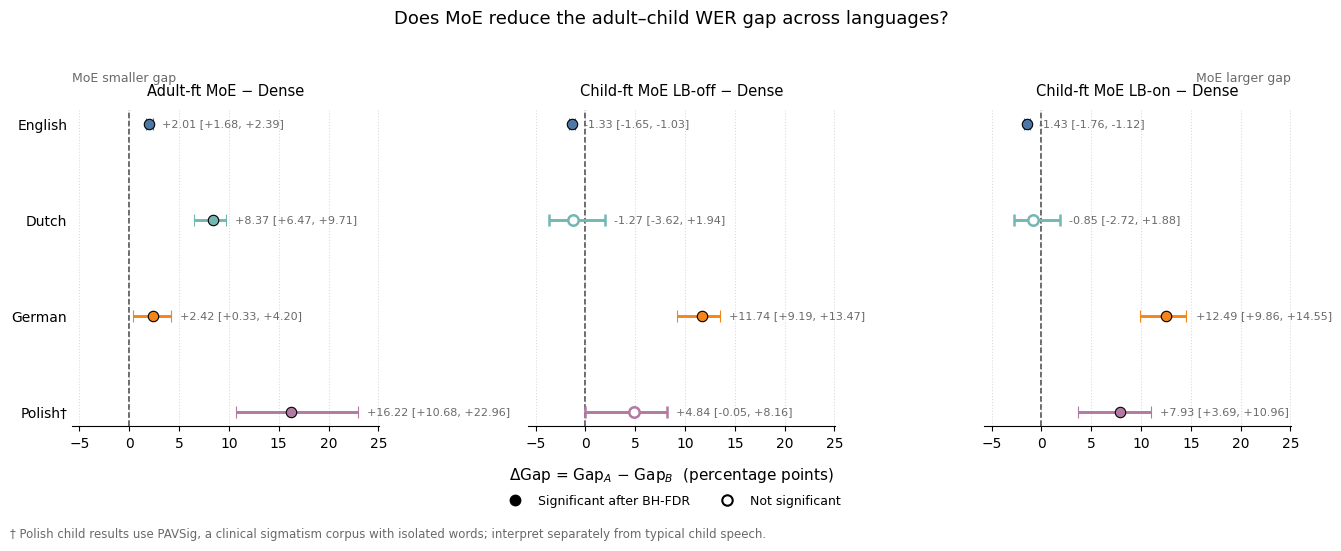

Saved:
/lp-dev/amelia/inclusive-asr-moe/stats/cache_multilingual/fig_rq_multilingual_gap_delta_forest.png
/lp-dev/amelia/inclusive-asr-moe/stats/cache_multilingual/fig_rq_multilingual_gap_delta_forest.pdf


In [15]:
# %% [markdown]
# ## 11. Thesis figure: adult-child WER gap reduction
#
# Primary statistical test:
# ΔGap = Gap_MoE - Gap_Dense
#
# Negative values mean Model A, usually MoE, has a smaller adult-child WER gap
# than Model B, usually Dense.
#
# Each point is the observed ΔGap.
# Each horizontal bar is the 95% paired speaker-level bootstrap CI.
# Filled markers indicate significance after BH-FDR correction.

# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Prepare dataframe ───────────────────────────────────────────────────────
plot_df = gap_res.copy()

pair_order = ["adult_ft", "child_LBoff", "child_LBon"]
lang_order = ["EN", "NL", "DE", "PL"]

pair_labels = {
    "adult_ft": "Adult-ft MoE − Dense",
    "child_LBoff": "Child-ft MoE LB-off − Dense",
    "child_LBon": "Child-ft MoE LB-on − Dense",
}

lang_labels = {
    "EN": "English",
    "NL": "Dutch",
    "DE": "German",
    "PL": "Polish†",
}

plot_df["Pair"] = pd.Categorical(plot_df["Pair"], categories=pair_order, ordered=True)
plot_df["Lang"] = pd.Categorical(plot_df["Lang"], categories=lang_order, ordered=True)
plot_df = plot_df.sort_values(["Pair", "Lang"]).reset_index(drop=True)

# ── Figure setup ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(pair_order),
    figsize=(13.5, 4.8),
    sharex=True,
    sharey=True
)

if len(pair_order) == 1:
    axes = [axes]

# Global x-limits from all confidence intervals
xmin = plot_df["CI low"].min()
xmax = plot_df["CI high"].max()
pad = 0.08 * (xmax - xmin if xmax > xmin else 1)

xmin = min(xmin - pad, -0.5)
xmax = max(xmax + pad, 0.5)

# Colors by language
lang_colors = {
    "EN": "#4C78A8",
    "NL": "#72B7B2",
    "DE": "#F58518",
    "PL": "#B279A2",
}

# ── Plot each model-pair panel ──────────────────────────────────────────────
for ax, pair in zip(axes, pair_order):
    sub = plot_df[plot_df["Pair"] == pair].copy()

    # y positions: EN top, PL bottom
    sub["y"] = sub["Lang"].map({lang: len(lang_order) - 1 - i for i, lang in enumerate(lang_order)})

    for _, row in sub.iterrows():
        lang = str(row["Lang"])
        y = row["y"]
        x = row["dGap (pp)"]
        lo = row["CI low"]
        hi = row["CI high"]

        color = lang_colors[lang]

        # CI + point
        ax.errorbar(
            x=x,
            y=y,
            xerr=[[x - lo], [hi - x]],
            fmt="o",
            markersize=7.5,
            linewidth=2.1,
            capsize=4,
            capthick=1.7,
            color=color,
            markerfacecolor=color if row["Significant"] else "white",
            markeredgecolor="black" if row["Significant"] else color,
            markeredgewidth=0.8 if row["Significant"] else 1.8,
            zorder=3
        )

        # Numeric label
        label = f"{x:+.2f} [{lo:+.2f}, {hi:+.2f}]"
        ax.text(
            hi + 0.03 * (xmax - xmin),
            y,
            label,
            va="center",
            ha="left",
            fontsize=8,
            color="dimgray"
        )

    # Reference line: no gap change
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.1,
        alpha=0.75,
        zorder=1
    )

    ax.set_title(pair_labels[pair], fontsize=10.5, pad=10)

    ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.45)
    ax.grid(axis="y", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.tick_params(axis="y", length=0)

# ── Y-axis labels ───────────────────────────────────────────────────────────
y_positions = [len(lang_order) - 1 - i for i in range(len(lang_order))]
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels([lang_labels[l] for l in lang_order], fontsize=10)

# ── Shared labels ───────────────────────────────────────────────────────────
fig.supxlabel(
    r"$\Delta$Gap = Gap$_A$ − Gap$_B$  (percentage points)",
    fontsize=11,
    y=0.03
)

fig.suptitle(
    "Does MoE reduce the adult–child WER gap across languages?",
    fontsize=13,
    y=1.02
)

# Direction labels
axes[0].text(
    0.00,
    1.08,
    "MoE smaller gap",
    transform=axes[0].transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    color="dimgray"
)

axes[-1].text(
    1.00,
    1.08,
    "MoE larger gap",
    transform=axes[-1].transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="dimgray"
)

# Same x-limits for all panels
for ax in axes:
    ax.set_xlim(xmin, xmax)

# Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=7.5,
        label="Significant after BH-FDR"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        markersize=7.5,
        label="Not significant"
    ),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=2,
    frameon=False,
    fontsize=9
)

# Caveat note
fig.text(
    0.01,
    -0.06,
    "† Polish child results use PAVSig, a clinical sigmatism corpus with isolated words; interpret separately from typical child speech.",
    ha="left",
    va="top",
    fontsize=8.5,
    color="dimgray"
)

plt.tight_layout()

# Save thesis-ready files
out_png = os.path.join(CACHE, "fig_rq_multilingual_gap_delta_forest.png")
out_pdf = os.path.join(CACHE, "fig_rq_multilingual_gap_delta_forest.pdf")

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

print("Saved:")
print(out_png)
print(out_pdf)

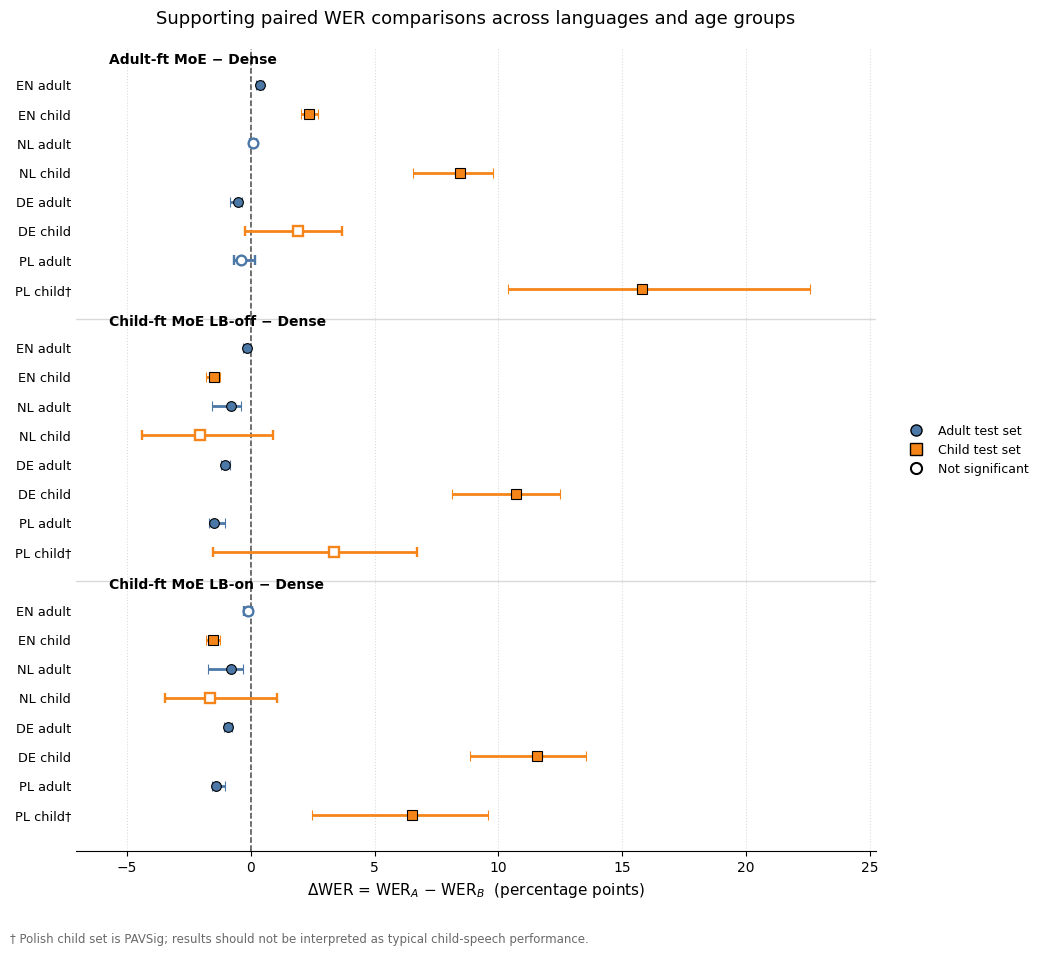

Saved:
/lp-dev/amelia/inclusive-asr-moe/stats/cache_multilingual/fig_rq_multilingual_supporting_delta_wer_forest.png
/lp-dev/amelia/inclusive-asr-moe/stats/cache_multilingual/fig_rq_multilingual_supporting_delta_wer_forest.pdf


In [17]:
# %% [markdown]
# ## 12. Supporting figure: paired WER differences by language and age group
#
# Supporting statistical test:
# ΔWER = WER_A - WER_B
#
# Negative values mean Model A has lower WER than Model B.
# This figure helps explain whether the ΔGap effect is driven by adult speech,
# child speech, or both.

# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plot_df = paired_res.copy()

# Keep RQ pairs only for this supporting figure.
# The LB effect is conceptually different and can be plotted separately if needed.
plot_df = plot_df[plot_df["Pair"].isin(["adult_ft", "child_LBoff", "child_LBon"])].copy()

pair_order = ["adult_ft", "child_LBoff", "child_LBon"]
lang_order = ["EN", "NL", "DE", "PL"]
age_order = ["adult", "child"]

pair_labels = {
    "adult_ft": "Adult-ft MoE − Dense",
    "child_LBoff": "Child-ft MoE LB-off − Dense",
    "child_LBon": "Child-ft MoE LB-on − Dense",
}

plot_df["Pair"] = pd.Categorical(plot_df["Pair"], categories=pair_order, ordered=True)
plot_df["Lang"] = pd.Categorical(plot_df["Lang"], categories=lang_order, ordered=True)
plot_df["Age"] = pd.Categorical(plot_df["Age"], categories=age_order, ordered=True)
plot_df = plot_df.sort_values(["Pair", "Lang", "Age"]).reset_index(drop=True)

age_colors = {
    "adult": "#4C78A8",
    "child": "#F58518",
}

age_markers = {
    "adult": "o",
    "child": "s",
}

# Build rows with spacers between model-pair groups
rows = []
y = 0
current_pair = None

for _, row in plot_df.iterrows():
    if current_pair is not None and row["Pair"] != current_pair:
        rows.append({"is_spacer": True, "y": y})
        y += 1

    r = row.to_dict()
    r["is_spacer"] = False
    r["y"] = y
    rows.append(r)
    y += 1
    current_pair = row["Pair"]

plot_df2 = pd.DataFrame(rows)

max_y = plot_df2["y"].max()
plot_df2["y_plot"] = max_y - plot_df2["y"]

data_df = plot_df2[~plot_df2["is_spacer"]].copy()

fig, ax = plt.subplots(figsize=(10.5, 9.2))

for _, row in data_df.iterrows():
    age = str(row["Age"])
    color = age_colors[age]
    marker = age_markers[age]

    x = row["diff (pp)"]
    lo = row["CI low"]
    hi = row["CI high"]
    y = row["y_plot"]

    ax.errorbar(
        x=x,
        y=y,
        xerr=[[x - lo], [hi - x]],
        fmt=marker,
        markersize=7,
        linewidth=2,
        capsize=3.8,
        capthick=1.6,
        color=color,
        markerfacecolor=color if row["Significant"] else "white",
        markeredgecolor="black" if row["Significant"] else color,
        markeredgewidth=0.8 if row["Significant"] else 1.7,
        zorder=3
    )

# Zero reference line
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.1,
    alpha=0.75,
    zorder=1
)

# Group separators
for _, row in plot_df2[plot_df2["is_spacer"]].iterrows():
    ax.axhline(
        row["y_plot"],
        color="0.85",
        linewidth=1,
        zorder=0
    )

# Row labels
yticks = []
yticklabels = []

for _, row in data_df.iterrows():
    lang = str(row["Lang"])
    age = str(row["Age"])
    caveat = "†" if lang == "PL" and age == "child" else ""
    yticklabels.append(f"{lang} {age}{caveat}")
    yticks.append(row["y_plot"])

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=9.3)

# Group headers
for pair, sub in data_df.groupby("Pair", sort=False):
    y_top = sub["y_plot"].max()
    ax.text(
        ax.get_xlim()[0],
        y_top + 0.65,
        pair_labels[str(pair)],
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

# Labels and title
ax.set_xlabel(
    r"$\Delta$WER = WER$_A$ − WER$_B$  (percentage points)",
    fontsize=11
)

ax.set_title(
    "Supporting paired WER comparisons across languages and age groups",
    fontsize=13,
    pad=18
)



# X limits
xmin = data_df["CI low"].min()
xmax = data_df["CI high"].max()
pad = 0.10 * (xmax - xmin if xmax > xmin else 1)
ax.set_xlim(min(xmin - pad, -0.5), max(xmax + pad, 0.5))

# Legend
legend_elements = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=age_colors["adult"],
           markeredgecolor="black", markersize=8, label="Adult test set"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor=age_colors["child"],
           markeredgecolor="black", markersize=8, label="Child test set"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
           markeredgecolor="black", markeredgewidth=1.5, markersize=8,
           label="Not significant"),
]

ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9
)

# Caveat note
fig.text(
    0.01,
    -0.02,
    "† Polish child set is PAVSig; results should not be interpreted as typical child-speech performance.",
    ha="left",
    va="top",
    fontsize=8.5,
    color="dimgray"
)

# Styling
ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.45)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)

plt.tight_layout()

out_png = os.path.join(CACHE, "fig_rq_multilingual_supporting_delta_wer_forest.png")
out_pdf = os.path.join(CACHE, "fig_rq_multilingual_supporting_delta_wer_forest.pdf")

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

print("Saved:")
print(out_png)
print(out_pdf)

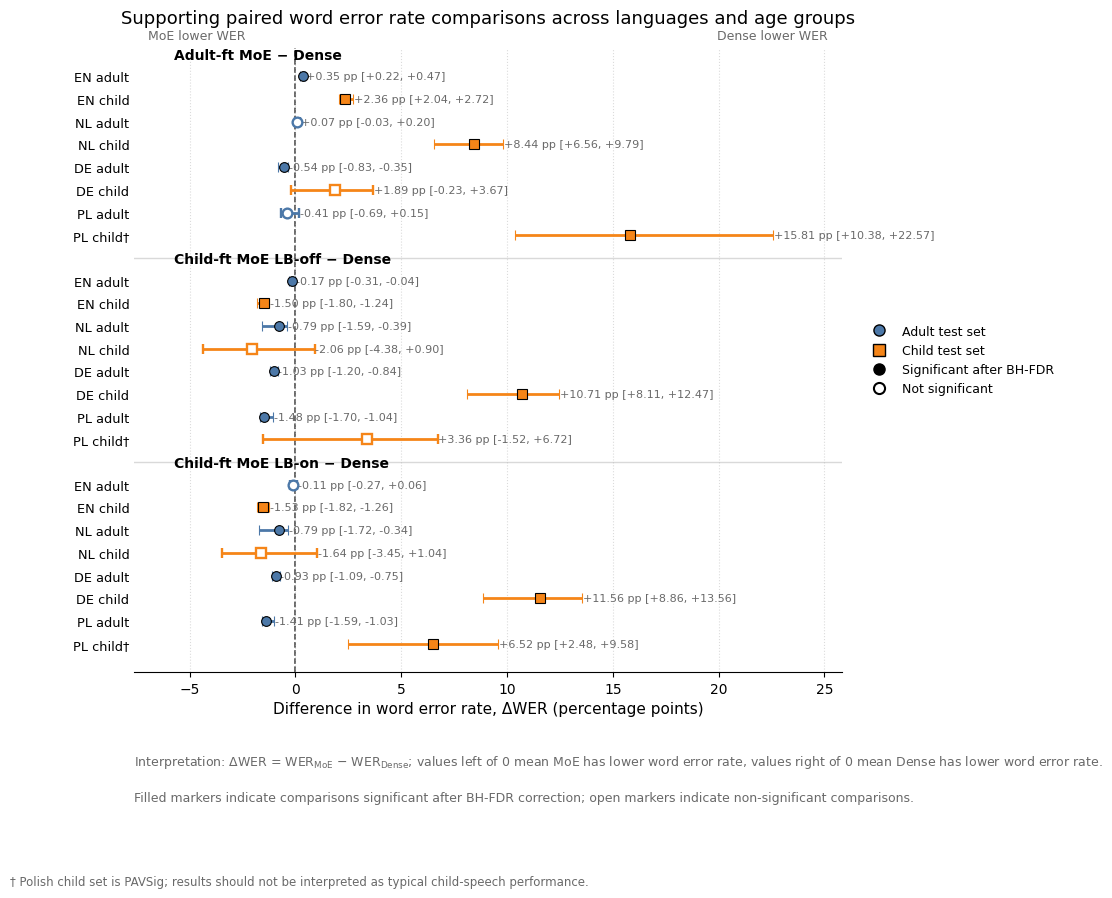

Saved:
/lp-dev/amelia/inclusive-asr-moe/stats/cache_multilingual/fig_rq_multilingual_supporting_delta_wer_forest_interpretable.png
/lp-dev/amelia/inclusive-asr-moe/stats/cache_multilingual/fig_rq_multilingual_supporting_delta_wer_forest_interpretable.pdf


In [18]:
# %% [markdown]
# ## 12. Supporting figure: paired WER differences by language and age group
#
# Supporting statistical test:
# ΔWER = WER_MoE - WER_Dense
#
# Negative values mean MoE has lower word error rate than Dense.
# Positive values mean Dense has lower word error rate than MoE.
# This figure helps explain whether the ΔGap effect is driven by adult speech,
# child speech, or both.

# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Check required object ───────────────────────────────────────────────────
if "paired_res" not in globals():
    raise RuntimeError(
        "paired_res is not defined. Run the paired comparison cells before running this figure."
    )

plot_df = paired_res.copy()

# Keep RQ pairs only for this supporting figure.
# The LB effect is conceptually different and can be plotted separately if needed.
plot_df = plot_df[plot_df["Pair"].isin(["adult_ft", "child_LBoff", "child_LBon"])].copy()

pair_order = ["adult_ft", "child_LBoff", "child_LBon"]
lang_order = ["EN", "NL", "DE", "PL"]
age_order = ["adult", "child"]

pair_labels = {
    "adult_ft": "Adult-ft MoE − Dense",
    "child_LBoff": "Child-ft MoE LB-off − Dense",
    "child_LBon": "Child-ft MoE LB-on − Dense",
}

plot_df["Pair"] = pd.Categorical(plot_df["Pair"], categories=pair_order, ordered=True)
plot_df["Lang"] = pd.Categorical(plot_df["Lang"], categories=lang_order, ordered=True)
plot_df["Age"] = pd.Categorical(plot_df["Age"], categories=age_order, ordered=True)
plot_df = plot_df.sort_values(["Pair", "Lang", "Age"]).reset_index(drop=True)

age_colors = {
    "adult": "#4C78A8",
    "child": "#F58518",
}

age_markers = {
    "adult": "o",
    "child": "s",
}

# Build rows with spacers between model-pair groups
rows = []
y = 0
current_pair = None

for _, row in plot_df.iterrows():
    if current_pair is not None and row["Pair"] != current_pair:
        rows.append({"is_spacer": True, "y": y})
        y += 1

    r = row.to_dict()
    r["is_spacer"] = False
    r["y"] = y
    rows.append(r)
    y += 1
    current_pair = row["Pair"]

plot_df2 = pd.DataFrame(rows)

max_y = plot_df2["y"].max()
plot_df2["y_plot"] = max_y - plot_df2["y"]

data_df = plot_df2[~plot_df2["is_spacer"]].copy()

fig, ax = plt.subplots(figsize=(10.8, 9.6))

for _, row in data_df.iterrows():
    age = str(row["Age"])
    color = age_colors[age]
    marker = age_markers[age]

    x = row["diff (pp)"]
    lo = row["CI low"]
    hi = row["CI high"]
    y = row["y_plot"]

    ax.errorbar(
        x=x,
        y=y,
        xerr=[[x - lo], [hi - x]],
        fmt=marker,
        markersize=7,
        linewidth=2,
        capsize=3.8,
        capthick=1.6,
        color=color,
        markerfacecolor=color if row["Significant"] else "white",
        markeredgecolor="black" if row["Significant"] else color,
        markeredgewidth=0.8 if row["Significant"] else 1.7,
        zorder=3
    )

    # Optional numeric annotation
    ax.text(
        hi + 0.04,
        y,
        f"{x:+.2f} pp [{lo:+.2f}, {hi:+.2f}]",
        va="center",
        ha="left",
        fontsize=8,
        color="dimgray"
    )

# Zero reference line
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.1,
    alpha=0.75,
    zorder=1
)

# Group separators
for _, row in plot_df2[plot_df2["is_spacer"]].iterrows():
    ax.axhline(
        row["y_plot"],
        color="0.85",
        linewidth=1,
        zorder=0
    )

# Row labels
yticks = []
yticklabels = []

for _, row in data_df.iterrows():
    lang = str(row["Lang"])
    age = str(row["Age"])
    caveat = "†" if lang == "PL" and age == "child" else ""
    yticklabels.append(f"{lang} {age}{caveat}")
    yticks.append(row["y_plot"])

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=9.3)

# Group headers
for pair, sub in data_df.groupby("Pair", sort=False):
    y_top = sub["y_plot"].max()
    ax.text(
        ax.get_xlim()[0],
        y_top + 0.65,
        pair_labels[str(pair)],
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

# Labels and title
ax.set_xlabel(
    "Difference in word error rate, ΔWER (percentage points)",
    fontsize=11
)

ax.set_title(
    "Supporting paired word error rate comparisons across languages and age groups",
    fontsize=13,
    pad=18
)

# X limits with extra room for annotations
xmin = data_df["CI low"].min()
xmax = data_df["CI high"].max()
pad = 0.12 * (xmax - xmin if xmax > xmin else 1)
ax.set_xlim(min(xmin - pad, -0.5), max(xmax + pad, 0.5))

# Direction labels
ax.text(
    0.02,
    1.01,
    "MoE lower WER",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    color="dimgray"
)

ax.text(
    0.98,
    1.01,
    "Dense lower WER",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="dimgray"
)

# Bottom interpretation text
ax.text(
    0.00,
    -0.13,
    r"Interpretation: $\Delta$WER = WER$_{\mathrm{MoE}}$ − WER$_{\mathrm{Dense}}$; "
    r"values left of 0 mean MoE has lower word error rate, values right of 0 mean Dense has lower word error rate.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="dimgray"
)

ax.text(
    0.00,
    -0.19,
    "Filled markers indicate comparisons significant after BH-FDR correction; open markers indicate non-significant comparisons.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="dimgray"
)

# Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=age_colors["adult"],
        markeredgecolor="black",
        markersize=8,
        label="Adult test set"
    ),
    Line2D(
        [0], [0],
        marker="s",
        color="none",
        markerfacecolor=age_colors["child"],
        markeredgecolor="black",
        markersize=8,
        label="Child test set"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=8,
        label="Significant after BH-FDR"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        markersize=8,
        label="Not significant"
    ),
]

ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9
)

# Caveat note
fig.text(
    0.01,
    0.005,
    "† Polish child set is PAVSig; results should not be interpreted as typical child-speech performance.",
    ha="left",
    va="bottom",
    fontsize=8.5,
    color="dimgray"
)

# Styling
ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.45)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)

# Space for legend and interpretation text
plt.subplots_adjust(bottom=0.23, right=0.78)

out_png = os.path.join(CACHE, "fig_rq_multilingual_supporting_delta_wer_forest_interpretable.png")
out_pdf = os.path.join(CACHE, "fig_rq_multilingual_supporting_delta_wer_forest_interpretable.pdf")

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

print("Saved:")
print(out_png)
print(out_pdf)